## Understand the Business Objective
### Goal of analysis
- Identify overstocked SKUs
- Identify low-stock / risk SKUs
- Analyze inventory aging
- Measure weeks of cover
- Improve inventory planning decisions

# Load & Inspect Data

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("datasets/Inventory_Health.csv")

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   SKU                      50 non-null     object 
 1   condition                50 non-null     object 
 2   total-inventory          48 non-null     float64
 3   available                50 non-null     int64  
 4   inbound-shipped          50 non-null     int64  
 5   inbound-received         50 non-null     int64  
 6   reserved-quantity        50 non-null     int64  
 7   unfulfillable-quantity   50 non-null     int64  
 8   inv-age-0-to-30-days     50 non-null     int64  
 9   inv-age-31-to-60-days    50 non-null     int64  
 10  inv-age-61-to-90-days    50 non-null     int64  
 11  inv-age-181-to-330-days  50 non-null     int64  
 12  inv-age-331-to-365-days  50 non-null     int64  
 13  inv-age-365-plus-days    50 non-null     int64  
 14  currency                 50 

In [42]:
df.columns

Index(['SKU', 'condition', 'total-inventory', 'available', 'inbound-shipped',
       'inbound-received', 'reserved-quantity', 'unfulfillable-quantity',
       'inv-age-0-to-30-days', 'inv-age-31-to-60-days',
       'inv-age-61-to-90-days', 'inv-age-181-to-330-days',
       'inv-age-331-to-365-days', 'inv-age-365-plus-days', 'currency',
       'units-shipped-t7', 'units-shipped-t30', 'units-shipped-t60',
       'units-shipped-t90', 'sell-through', 'item-volume',
       'volume-unit-measurement', 'storage-type', 'storage-volume',
       'marketplace', 'days-of-supply', 'weeks-of-cover-t30',
       'weeks-of-cover-t90'],
      dtype='object')

In [43]:
df.head()

,SKU,condition,total-inventory,available,inbound-shipped,inbound-received,reserved-quantity,unfulfillable-quantity,inv-age-0-to-30-days,inv-age-31-to-60-days,...,units-shipped-t90,sell-through,item-volume,volume-unit-measurement,storage-type,storage-volume,marketplace,days-of-supply,weeks-of-cover-t30,weeks-of-cover-t90
0,MN-01,New,382.0,264,40,9,68,1,12,261,...,574,1.33,0.546781,cubic feet,Standard,144.350184,US,47,6,7
1,MN-02,New,306.0,206,80,2,18,0,127,91,...,417,1.56,0.373971,cubic feet,Standard,77.038026,US,85,7,8
2,MN-03,New,139.0,95,40,0,3,1,42,8,...,179,1.16,0.425846,cubic feet,Standard,40.455370,US,83,8,9
3,MN-04,New,171.0,70,80,8,13,0,3,84,...,187,1.65,0.375575,cubic feet,Standard,26.290250,US,99,8,10
4,MN-05,New,283.0,0,0,49,234,0,53,141,...,557,1.47,0.270417,cubic feet,Standard,0.000000,US,145,0,1


# Data Quality Checks

In [44]:
df.isnull().sum()

SKU                        0
condition                  0
total-inventory            2
available                  0
inbound-shipped            0
inbound-received           0
reserved-quantity          0
unfulfillable-quantity     0
inv-age-0-to-30-days       0
inv-age-31-to-60-days      0
inv-age-61-to-90-days      0
inv-age-181-to-330-days    0
inv-age-331-to-365-days    0
inv-age-365-plus-days      0
currency                   0
units-shipped-t7           0
units-shipped-t30          0
units-shipped-t60          0
units-shipped-t90          0
sell-through               0
item-volume                0
volume-unit-measurement    0
storage-type               0
storage-volume             0
marketplace                0
days-of-supply             0
weeks-of-cover-t30         0
weeks-of-cover-t90         0
dtype: int64

In [45]:
df['total-inventory'] = pd.to_numeric(df['total-inventory'], errors='coerce')

In [46]:
df['total-inventory'] = df['total-inventory'].fillna(
    df['available'] + df['reserved-quantity'] + df['unfulfillable-quantity'])

In [47]:
df['total-inventory'].head()

0    382.0
1    306.0
2    139.0
3    171.0
4    283.0
Name: total-inventory, dtype: float64

In [48]:
df.isnull().sum()

SKU                        0
condition                  0
total-inventory            0
available                  0
inbound-shipped            0
inbound-received           0
reserved-quantity          0
unfulfillable-quantity     0
inv-age-0-to-30-days       0
inv-age-31-to-60-days      0
inv-age-61-to-90-days      0
inv-age-181-to-330-days    0
inv-age-331-to-365-days    0
inv-age-365-plus-days      0
currency                   0
units-shipped-t7           0
units-shipped-t30          0
units-shipped-t60          0
units-shipped-t90          0
sell-through               0
item-volume                0
volume-unit-measurement    0
storage-type               0
storage-volume             0
marketplace                0
days-of-supply             0
weeks-of-cover-t30         0
weeks-of-cover-t90         0
dtype: int64

In [49]:
df.describe()

,total-inventory,available,inbound-shipped,inbound-received,reserved-quantity,unfulfillable-quantity,inv-age-0-to-30-days,inv-age-31-to-60-days,inv-age-61-to-90-days,inv-age-181-to-330-days,...,units-shipped-t7,units-shipped-t30,units-shipped-t60,units-shipped-t90,sell-through,item-volume,storage-volume,days-of-supply,weeks-of-cover-t30,weeks-of-cover-t90
count,50.000000,50.000000,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000,50.00000,50.000000,...,50.000000,50.000000,50.000000,50.000000,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,479.300000,316.060000,105.00000,12.440000,47.800000,2.340000,160.500000,207.860000,25.88000,0.340000,...,70.320000,308.700000,544.400000,780.240000,1.55480,0.290333,92.797665,77.600000,8.580000,9.760000
std,391.094552,284.894281,176.70187,28.095435,41.893938,4.533819,193.035394,256.338584,53.64039,2.404163,...,64.390847,311.913858,576.909323,789.173853,0.47654,0.179913,97.073248,31.653739,14.245787,12.704748
min,18.000000,0.000000,0.00000,0.000000,3.000000,0.000000,1.000000,0.000000,0.00000,0.000000,...,2.000000,10.000000,18.000000,36.000000,0.36000,0.017404,0.000000,0.000000,0.000000,0.000000
25%,212.500000,112.500000,0.00000,0.000000,16.500000,0.000000,23.500000,49.000000,0.00000,0.000000,...,24.000000,120.500000,180.750000,266.500000,1.28750,0.161145,24.624434,63.250000,4.250000,6.000000
50%,350.500000,235.500000,60.00000,4.500000,40.000000,1.000000,83.000000,117.500000,0.00000,0.000000,...,47.500000,197.000000,322.000000,467.000000,1.58000,0.274906,58.446105,79.500000,6.000000,8.000000
75%,628.000000,390.750000,115.00000,11.500000,67.750000,2.000000,222.750000,222.500000,42.50000,0.000000,...,104.250000,453.000000,688.500000,1159.500000,1.80750,0.376449,143.323204,89.750000,8.000000,10.000000
max,1645.000000,1079.000000,1100.00000,181.000000,234.000000,25.000000,764.000000,1202.000000,258.00000,17.000000,...,249.000000,1729.000000,3336.000000,4300.000000,3.18000,0.912420,446.926284,159.000000,98.000000,89.000000


### Key metrics to observe:
- Average inventory per SKU
- Max / min stock
- Distribution of weeks of cover

In [50]:
df['reserved_ratio'] = df['reserved-quantity'] / df['total-inventory']
df[['SKU', 'available', 'reserved_ratio']].head()

,SKU,available,reserved_ratio
0,MN-01,264,0.178010
1,MN-02,206,0.058824
2,MN-03,95,0.021583
3,MN-04,70,0.076023
4,MN-05,0,0.826855


- reserved_ratio > 0.4 → high demand pressure
- Low availability + high reserved = stock-out risk

## Cleaning data

In [51]:
cols_to_drop = [
    'currency',
    'volume-unit-measurement',
    'storage-type',
    'marketplace',
    'item-volume',
    'storage-volume'
]

df = df.drop(columns=cols_to_drop, errors='ignore')

In [52]:
 df.columns

Index(['SKU', 'condition', 'total-inventory', 'available', 'inbound-shipped',
       'inbound-received', 'reserved-quantity', 'unfulfillable-quantity',
       'inv-age-0-to-30-days', 'inv-age-31-to-60-days',
       'inv-age-61-to-90-days', 'inv-age-181-to-330-days',
       'inv-age-331-to-365-days', 'inv-age-365-plus-days', 'units-shipped-t7',
       'units-shipped-t30', 'units-shipped-t60', 'units-shipped-t90',
       'sell-through', 'days-of-supply', 'weeks-of-cover-t30',
       'weeks-of-cover-t90', 'reserved_ratio'],
      dtype='object')

In [53]:
df['aged_inventory_90_plus'] = (
    df['inv-age-181-to-330-days'] +
    df['inv-age-331-to-365-days'] +
    df['inv-age-365-plus-days']
)


In [54]:
df = df.drop(columns=[
    'inv-age-181-to-330-days',
    'inv-age-331-to-365-days',
    'inv-age-365-plus-days'
])


In [55]:
df.head()

,SKU,condition,total-inventory,available,inbound-shipped,inbound-received,reserved-quantity,unfulfillable-quantity,inv-age-0-to-30-days,inv-age-31-to-60-days,...,units-shipped-t7,units-shipped-t30,units-shipped-t60,units-shipped-t90,sell-through,days-of-supply,weeks-of-cover-t30,weeks-of-cover-t90,reserved_ratio,aged_inventory_90_plus
0,MN-01,New,382.0,264,40,9,68,1,12,261,...,59,203,386,574,1.33,47,6,7,0.178010,0
1,MN-02,New,306.0,206,80,2,18,0,127,91,...,29,155,261,417,1.56,85,7,8,0.058824,0
2,MN-03,New,139.0,95,40,0,3,1,42,8,...,13,67,116,179,1.16,83,8,9,0.021583,0
3,MN-04,New,171.0,70,80,8,13,0,3,84,...,18,71,128,187,1.65,99,8,10,0.076023,0
4,MN-05,New,283.0,0,0,49,234,0,53,141,...,249,491,543,557,1.47,145,0,1,0.826855,0


## Create Aggregated Aging Column

In [56]:
df['aged_inventory_90_plus'] = (
    df.get('inv-age-181-to-330-days', 0) +
    df.get('inv-age-331-to-365-days', 0) +
    df.get('inv-age-365-plus-days', 0)
)


## Final Clean Column Set

In [57]:
final_columns = [
    'SKU',
    'total-inventory',
    'available',
    'reserved-quantity',
    'unfulfillable-quantity',

    'inbound-shipped',
    'inbound-received',

    'inv-age-0-to-30-days',
    'inv-age-31-to-60-days',
    'inv-age-61-to-90-days',
    'aged_inventory_90_plus',

    'units-shipped-t7',
    'units-shipped-t30',
    'units-shipped-t60',
    'units-shipped-t90',

    'sell-through',
    'days-of-supply',
    'weeks-of-cover-t30',
    'weeks-of-cover-t90',

    'reserved_ratio'
]


In [58]:
df = df[[col for col in final_columns if col in df.columns]]


## Final Sanity Checks

In [59]:
df.shape


(50, 20)

In [60]:
df.dtypes


SKU                        object
total-inventory           float64
available                   int64
reserved-quantity           int64
unfulfillable-quantity      int64
inbound-shipped             int64
inbound-received            int64
inv-age-0-to-30-days        int64
inv-age-31-to-60-days       int64
inv-age-61-to-90-days       int64
aged_inventory_90_plus      int64
units-shipped-t7            int64
units-shipped-t30           int64
units-shipped-t60           int64
units-shipped-t90           int64
sell-through              float64
days-of-supply              int64
weeks-of-cover-t30          int64
weeks-of-cover-t90          int64
reserved_ratio            float64
dtype: object

## Create High-Value Insight Flags

## Dead stock flag

In [61]:
df['dead_stock'] = (
    (df['weeks-of-cover-t90'] == 0) &
    (df['total-inventory'] > 0)
)


In [62]:
df['dead_stock'].sum()

2

## Overstock flag

In [63]:
df['overstock'] = df['weeks-of-cover-t90'] > 12


In [64]:
df['overstock'].sum()

4

## Stock-out risk flag

In [65]:
df['stockout_risk'] = (
    (df['weeks-of-cover-t90'] < 4) &
    (df['available'] < 10)
)


In [66]:
df['stockout_risk'].sum()

3

### Removed noisy & metadata columns
- Preserved business meaning of zeros
- Created aggregated aging insight
- Added decision-ready flags
- Generated a clean, reusable dataset

In [68]:
num_cols = [
    'total-inventory','available','reserved-quantity',
    'inv-age-0-to-30-days','inv-age-31-to-60-days','inv-age-61-to-90-days',
    'units-shipped-t90','weeks-of-cover-t90'
]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

# Create aggregated aging column (90+ days)
df['aged_inventory_90_plus'] = (
    df.get('inv-age-181-to-330-days', 0) +
    df.get('inv-age-331-to-365-days', 0) +
    df.get('inv-age-365-plus-days', 0)
)

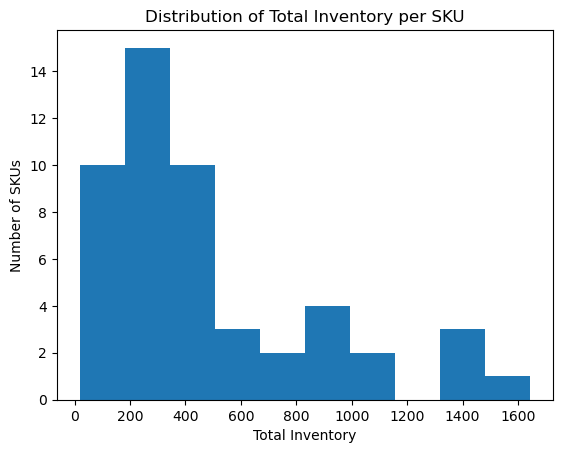

In [69]:
# 1. Distribution of Total Inventory
# --------------------------------------------------
plt.figure()
df['total-inventory'].dropna().plot(kind='hist', bins=10)
plt.title("Distribution of Total Inventory per SKU")
plt.xlabel("Total Inventory")
plt.ylabel("Number of SKUs")
plt.show()


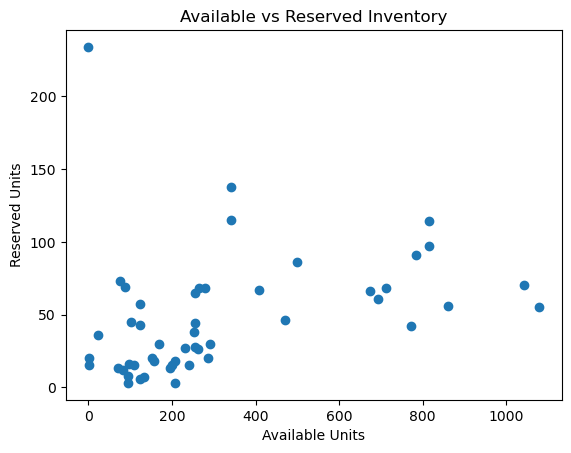

In [70]:
# 2. Available vs Reserved Inventory
# --------------------------------------------------
plt.figure()
plt.scatter(df['available'], df['reserved-quantity'])
plt.title("Available vs Reserved Inventory")
plt.xlabel("Available Units")
plt.ylabel("Reserved Units")
plt.show()

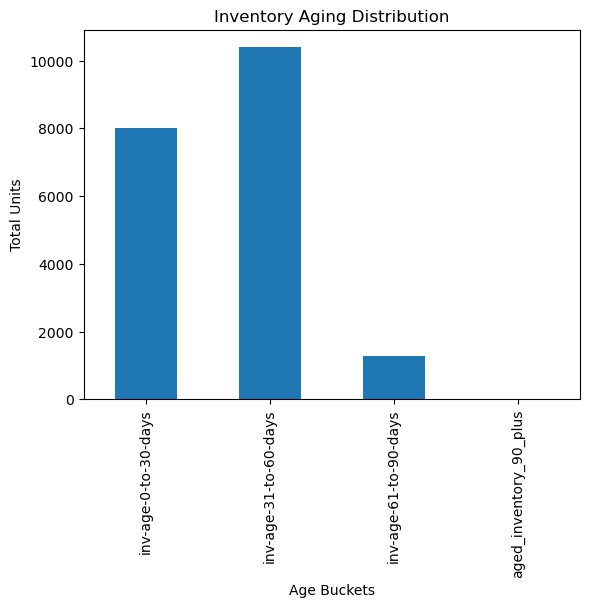

In [78]:
# 3. Inventory Aging Distribution
# --------------------------------------------------
plt.figure()
age_cols = [
    'inv-age-0-to-30-days',
    'inv-age-31-to-60-days',
    'inv-age-61-to-90-days',
    'aged_inventory_90_plus'
]
df[age_cols].sum().plot(kind='bar')
plt.title("Inventory Aging Distribution")
plt.xlabel("Age Buckets")
plt.ylabel("Total Units")
plt.show()

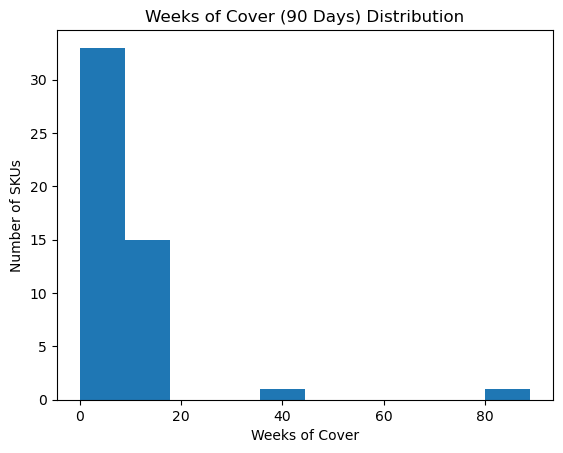

In [72]:
# 4. Weeks of Cover Distribution (90 Days)
# --------------------------------------------------
plt.figure()
df['weeks-of-cover-t90'].dropna().plot(kind='hist', bins=10)
plt.title("Weeks of Cover (90 Days) Distribution")
plt.xlabel("Weeks of Cover")
plt.ylabel("Number of SKUs")
plt.show()

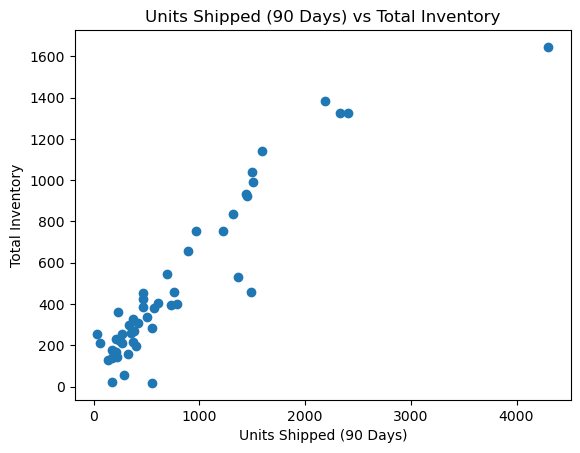

In [73]:
# 5. Sales vs Inventory
# --------------------------------------------------
plt.figure()
plt.scatter(df['units-shipped-t90'], df['total-inventory'])
plt.title("Units Shipped (90 Days) vs Total Inventory")
plt.xlabel("Units Shipped (90 Days)")
plt.ylabel("Total Inventory")
plt.show()

### What These Charts Cover
- Inventory distribution
- Availability vs reservations
- Aging bucket analysis
- Stock coverage risk
- Demand vs inventory imbalance

* I performed EDA using distribution plots, aging analysis, and sales-inventory relationships to identify overstock, dead stock, and stock-out risks.

# Save Clean Dataset

In [80]:
df.to_csv("inventory_health_cleaned.csv", index=False)